# Questão 4 - Runge-Kutta para Sistemas de EDOs de Primeira Ordem

Use o método de Runge-Kutta para sistemas para encontrar aproximações das soluções dos seguintes sistemas de equações diferenciais de primeira ordem e compare os resultados às soluções reais.

## Letra a)

$$
\begin{cases}
u_1' = u_1 - u_2 + 2, & u_1(0) = -1 \\
u_2' = -u_1 + u_2 + 4t, & u_2(0) = 0
\end{cases}
$$

para $0 \leq t \leq 1; \quad h = 0,1$

**Soluções reais:**

$$u_1(t) = -\frac{1}{2}e^{2t} + t^2 + 2t - \frac{1}{2}$$

$$u_2(t) = \frac{1}{2}e^{2t} + t^2 - \frac{1}{2}$$

## Letra b)

$$
\begin{cases}
u_1' = u_1 + 2u_2 - 2u_3 + e^{-t}, & u_1(0) = 3 \\
u_2' = u_2 + u_3 - 2e^{-t}, & u_2(0) = -1 \\
u_3' = u_1 + 2u_2 + e^{-t}, & u_3(0) = 1
\end{cases}
$$

para $0 \leq t \leq 1; \quad h = 0,1$

**Soluções reais:**

$$u_1(t) = -3e^{-t} - 3\sin t + 6\cos t$$

$$u_2(t) = \frac{3}{2}e^{-t} + \frac{3}{10}\sin t - \frac{21}{10}\cos t - \frac{2}{5}e^{2t}$$

$$u_3(t) = -e^{-t} + \frac{12}{5}\cos t + \frac{9}{5}\sin t - \frac{2}{5}e^{2t}$$

QUESTÃO 4 - LETRA A
t		u1 (aprox)		u1 (real)		u2 (aprox)		u2 (real)
--------------------------------------------------------------------------------
0.00		-1.0000000000	-1.0000000000	0.0000000000	0.0000000000
0.10		-0.9007000000	-0.9007013791	0.1207000000	0.1207013791
0.20		-0.8059089800	-0.8059123488	0.2859089800	0.2859123488
0.30		-0.7210532282	-0.7210594002	0.5010532282	0.5010594002
0.40		-0.6527604129	-0.6527704642	0.7727604129	0.7727704642
0.50		-0.6091255683	-0.6091409142	1.1091255683	1.1091409142
0.60		-0.6000359691	-0.6000584614	1.5200359691	1.5200584614
0.70		-0.6375679327	-0.6375999834	2.0175679327	2.0175999834
0.80		-0.7364714730	-0.7365162122	2.6164714730	2.6165162122
0.90		-0.9147622571	-0.9148237322	3.3347622571	3.3348237322
1.00		-1.1944446208	-1.1945280495	4.1944446208	4.1945280495

Erro máximo em u1: 0.0000834286
Erro máximo em u2: 0.0000834286
QUESTÃO 4 - LETRA B
t		u1 (aprox)		u1 (real)		u2 (aprox)		u2 (real)		u3 (aprox)		u3 (real)
0.00		3.0000000000	3.0000000000	-1.

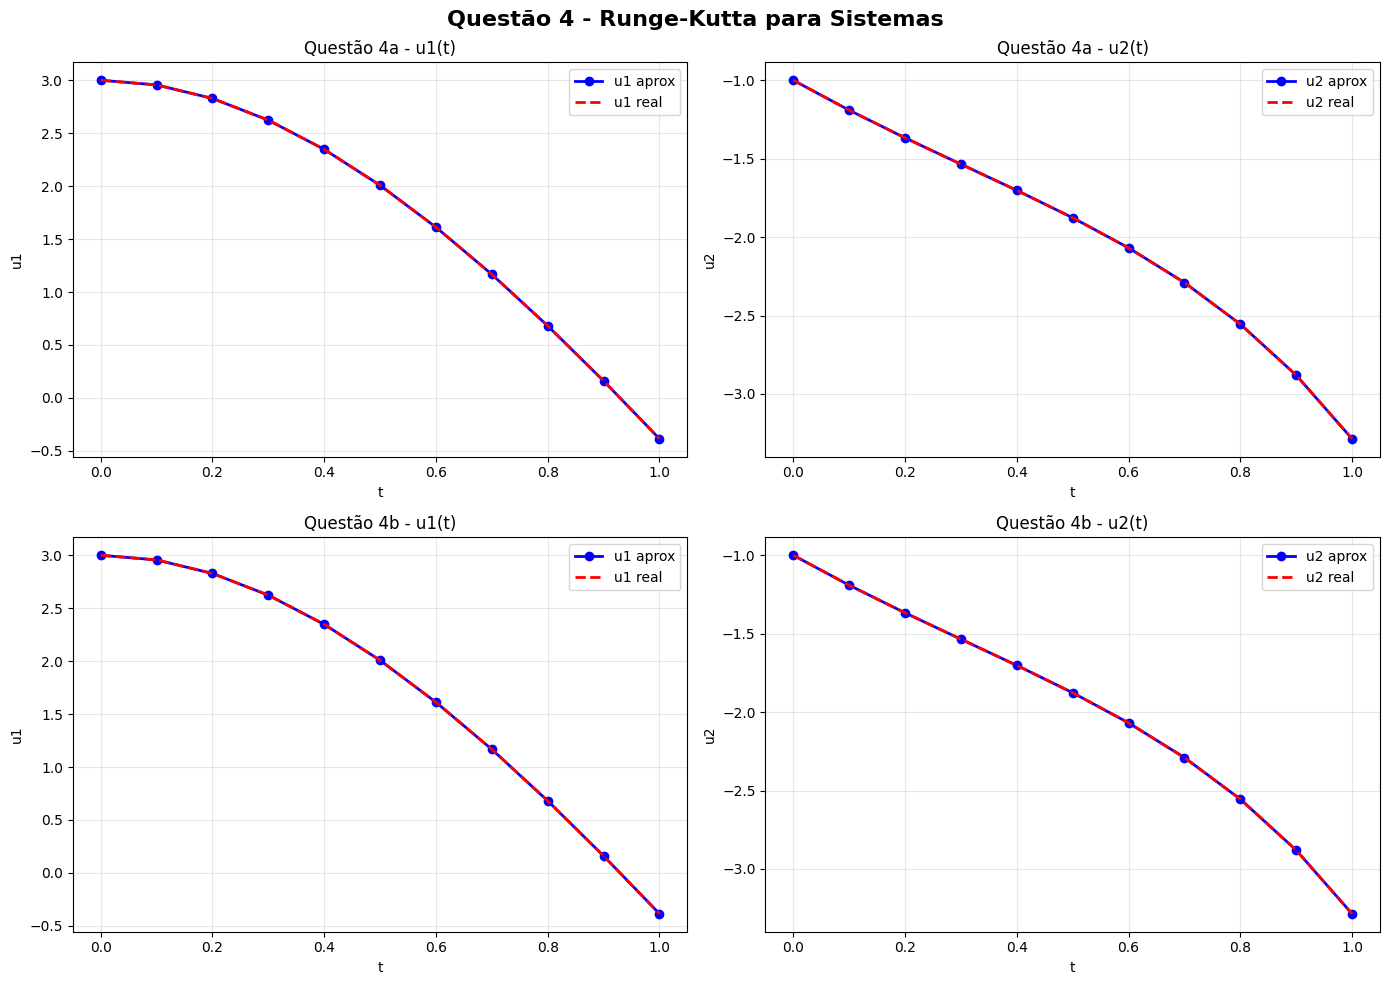

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rk4_system_2d(f1, f2, t0, u1_0, u2_0, h, t_end):
    """Runge-Kutta 4ª ordem para sistemas de 2 EDOs"""
    n = int((t_end - t0) / h)
    t = np.zeros(n+1)
    u1 = np.zeros(n+1)
    u2 = np.zeros(n+1)
    t[0] = t0
    u1[0] = u1_0
    u2[0] = u2_0
    
    for i in range(n):
        t_curr = t[i]
        u1_curr = u1[i]
        u2_curr = u2[i]
        
        k1_1 = f1(t_curr, u1_curr, u2_curr)
        k1_2 = f2(t_curr, u1_curr, u2_curr)
        
        k2_1 = f1(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2)
        k2_2 = f2(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2)
        
        k3_1 = f1(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2)
        k3_2 = f2(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2)
        
        k4_1 = f1(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2)
        k4_2 = f2(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2)
        
        u1[i+1] = u1_curr + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        u2[i+1] = u2_curr + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)
        t[i+1] = t_curr + h
    
    return t, u1, u2


def rk4_system_3d(f1, f2, f3, t0, u1_0, u2_0, u3_0, h, t_end):
    """Runge-Kutta 4ª ordem para sistemas de 3 EDOs"""
    n = int((t_end - t0) / h)
    t = np.zeros(n+1)
    u1 = np.zeros(n+1)
    u2 = np.zeros(n+1)
    u3 = np.zeros(n+1)
    t[0] = t0
    u1[0] = u1_0
    u2[0] = u2_0
    u3[0] = u3_0
    
    for i in range(n):
        t_curr = t[i]
        u1_curr = u1[i]
        u2_curr = u2[i]
        u3_curr = u3[i]
        
        k1_1 = f1(t_curr, u1_curr, u2_curr, u3_curr)
        k1_2 = f2(t_curr, u1_curr, u2_curr, u3_curr)
        k1_3 = f3(t_curr, u1_curr, u2_curr, u3_curr)
        
        k2_1 = f1(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        k2_2 = f2(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        k2_3 = f3(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        
        k3_1 = f1(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        k3_2 = f2(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        k3_3 = f3(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        
        k4_1 = f1(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        k4_2 = f2(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        k4_3 = f3(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        
        u1[i+1] = u1_curr + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        u2[i+1] = u2_curr + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)
        u3[i+1] = u3_curr + (h/6)*(k1_3 + 2*k2_3 + 2*k3_3 + k4_3)
        t[i+1] = t_curr + h
    
    return t, u1, u2, u3

# QUESTÃO 4 - LETRA A

def f4a1(t, u1, u2):
    return u1 - u2 + 2

def f4a2(t, u1, u2):
    return -u1 + u2 + 4*t

def sol4a1(t):
    return -0.5*np.exp(2*t) + t**2 + 2*t - 0.5

def sol4a2(t):
    return 0.5*np.exp(2*t) + t**2 - 0.5

print("QUESTÃO 4 - LETRA A")

t0, u1_0, u2_0, h, t_end = 0, -1, 0, 0.1, 1
t, u1, u2 = rk4_system_2d(f4a1, f4a2, t0, u1_0, u2_0, h, t_end)

u1_real = sol4a1(t)
u2_real = sol4a2(t)

print("t\t\tu1 (aprox)\t\tu1 (real)\t\tu2 (aprox)\t\tu2 (real)")
print("-"*80)
for i in range(len(t)):
    print(f"{t[i]:.2f}\t\t{u1[i]:.10f}\t{u1_real[i]:.10f}\t{u2[i]:.10f}\t{u2_real[i]:.10f}")

erro1 = np.max(np.abs(u1 - u1_real))
erro2 = np.max(np.abs(u2 - u2_real))
print(f"\nErro máximo em u1: {erro1:.10f}")
print(f"Erro máximo em u2: {erro2:.10f}")

# QUESTÃO 4 - LETRA B

def f4b1(t, u1, u2, u3):
    return u1 + 2*u2 - 2*u3 + np.exp(-t)

def f4b2(t, u1, u2, u3):
    return u2 + u3 - 2*np.exp(-t)

def f4b3(t, u1, u2, u3):
    return u1 + 2*u2 + np.exp(-t)

def sol4b1(t):
    return -3*np.exp(-t) - 3*np.sin(t) + 6*np.cos(t)

def sol4b2(t):
    return 1.5*np.exp(-t) + 0.3*np.sin(t) - 2.1*np.cos(t) - 0.4*np.exp(2*t)

def sol4b3(t):
    return -np.exp(-t) + 2.4*np.cos(t) + 1.8*np.sin(t) - 0.4*np.exp(2*t)

print("QUESTÃO 4 - LETRA B")

t0, u1_0, u2_0, u3_0, h, t_end = 0, 3, -1, 1, 0.1, 1
t, u1, u2, u3 = rk4_system_3d(f4b1, f4b2, f4b3, t0, u1_0, u2_0, u3_0, h, t_end)

u1_real = sol4b1(t)
u2_real = sol4b2(t)
u3_real = sol4b3(t)

print("t\t\tu1 (aprox)\t\tu1 (real)\t\tu2 (aprox)\t\tu2 (real)\t\tu3 (aprox)\t\tu3 (real)")

for i in range(len(t)):
    print(f"{t[i]:.2f}\t\t{u1[i]:.10f}\t{u1_real[i]:.10f}\t{u2[i]:.10f}\t{u2_real[i]:.10f}\t{u3[i]:.10f}\t{u3_real[i]:.10f}")

erro1 = np.max(np.abs(u1 - u1_real))
erro2 = np.max(np.abs(u2 - u2_real))
erro3 = np.max(np.abs(u3 - u3_real))
print(f"\nErro máximo em u1: {erro1:.10f}")
print(f"Erro máximo em u2: {erro2:.10f}")
print(f"Erro máximo em u3: {erro3:.10f}")

# GRÁFICOS

plt.figure(figsize=(14, 10))

# Letra A - u1
plt.subplot(2, 2, 1)
plt.plot(t, u1, 'bo-', linewidth=2, label='u1 aprox')
plt.plot(t, u1_real, 'r--', linewidth=2, label='u1 real')
plt.xlabel('t')
plt.ylabel('u1')
plt.title('Questão 4a - u1(t)')
plt.grid(True, alpha=0.3)
plt.legend()

# Letra A - u2
plt.subplot(2, 2, 2)
plt.plot(t, u2, 'bo-', linewidth=2, label='u2 aprox')
plt.plot(t, u2_real, 'r--', linewidth=2, label='u2 real')
plt.xlabel('t')
plt.ylabel('u2')
plt.title('Questão 4a - u2(t)')
plt.grid(True, alpha=0.3)
plt.legend()

# Letra B - u1
plt.subplot(2, 2, 3)
plt.plot(t, u1, 'bo-', linewidth=2, label='u1 aprox')
plt.plot(t, u1_real, 'r--', linewidth=2, label='u1 real')
plt.xlabel('t')
plt.ylabel('u1')
plt.title('Questão 4b - u1(t)')
plt.grid(True, alpha=0.3)
plt.legend()

# Letra B - u2
plt.subplot(2, 2, 4)
plt.plot(t, u2, 'bo-', linewidth=2, label='u2 aprox')
plt.plot(t, u2_real, 'r--', linewidth=2, label='u2 real')
plt.xlabel('t')
plt.ylabel('u2')
plt.title('Questão 4b - u2(t)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Questão 4 - Runge-Kutta para Sistemas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()